# ANÁLISIS DEL DATASET TITANIC 
## 1. IMPORTAR LIBRERÍAS

In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
import joblib  # Para guardar el modelo


## 2. CARGA Y EXPLORACIÓN (EDA)

### Cargar dataset

In [2]:
df = pd.read_csv('Titanic.csv')

### Mostrar estructura básica

In [3]:
print("Primeras filas del dataset:")
print(df.head())

Primeras filas del dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450 

### Ver valores faltantes

In [4]:
print("\nValores faltantes:")
print(df.isnull().sum())


Valores faltantes:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Visualizar distribución de supervivientes

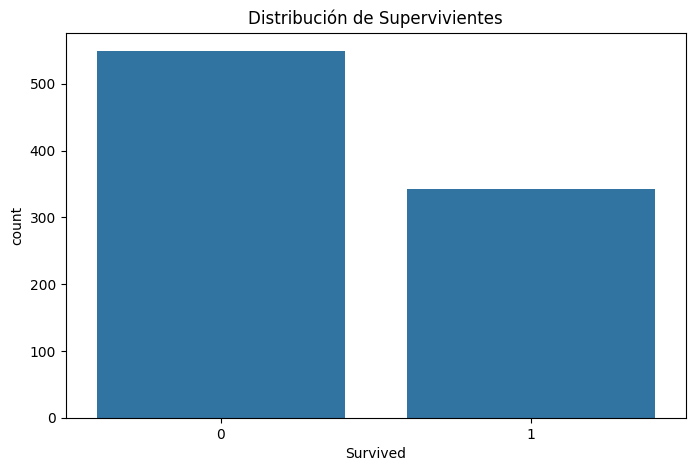

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(x='Survived', data=df)
plt.title('Distribución de Supervivientes')
plt.show()

## 3. PREPROCESAMIENTO DE DATOS

**SibSp**

Significado: Sibling + Spouse (Hermanos + Cónyuge).

Qué representa:
- Número de hermanos/hermanas (siblings) a bordo.
- Número de esposos/esposas (spouses) a bordo.

Ejemplo:

>SibSp = 1 → El pasajero viajaba con 1 hermano/hermana o con su esposo/esposa.

**Parch**

Significado: Parent + Child (Padres + Hijos).

Qué representa:
* Número de hijos/hijas (children) a bordo.
- Número de padres/madres (parents) a bordo.

Ejemplo:

>Parch = 2 → El pasajero viajaba con 2 hijos o con 1 padre y 1 madre.

### Crear nuevas caracteristicas 

In [6]:
df['family_size'] = df['SibSp'] + df['Parch']
df['is_alone'] = (df['family_size'] == 0).astype(int)

## Eliminar columnas no útiles

In [7]:
df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1, inplace=True)

### Definir variables para el modelo

In [8]:
cat_vars = ['Sex','Embarked','Pclass']  # Categóricas
num_vars = ['Age','Fare','SibSp','Parch','family_size','is_alone']  # Numéricas

### Pipeline para variables numéricas

In [9]:

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Imputar faltantes con mediana
    ('scaler', StandardScaler())  # Estandarizar valores
])


### Por que hay que estandarizar valores?

Media = 0 y Desviación Estándar = 1  
Imagina que estás comparando las edades (Age) y los precios de los tickets (Fare) de los pasajeros del Titanic. Estos datos están en escalas totalmente diferentes:

- Edad: Entre 0 y 80 años (valores pequeños).
- Precio del ticket: Entre £0 y £500 (valores grandes).

Si usas estos datos directamente en un modelo de machine learning (como una regresión logística para predecir supervivencia), el modelo podría darle más importancia al precio del ticket solo porque sus números son más grandes, incluso si la edad es más relevante para predecir quién sobrevivió. Aquí es donde entra la estandarización (StandardScaler).

¿Qué hace StandardScaler?
Transforma tus datos para que:

- Media = 0: El valor promedio de todos los datos se centra en cero.
- Desviación estándar = 1: La dispersión de los datos se ajusta a una escala uniforme.

### Pipeline para variables categóricas

In [10]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Usa la moda (ej: 'S' en Embarked)
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Convierte Sex (male/female) a 0/1
])

### Combinar transformaciones

In [11]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_vars),
        ('cat', categorical_transformer, cat_vars)
    ])


## 4. PREPARACIÓN DE DATOS
### Separar variables predictoras (X) y objetivo (y)

In [12]:

X = df.drop('Survived', axis=1)
y = df['Survived']


### Dividir en train (80%) y test (20%)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## 5. CREACIÓN Y ENTRENAMIENTO DE MODELOS
### Pipeline para Regresión Logística

In [14]:

logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])


### Entrenar modelo REGRESION LOGISTICA

In [15]:

logreg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Pipeline para RAMDOM FOREST

In [16]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

### Entrenar modelo

In [17]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 6. EVALUACIÓN DE MODELOS

In [18]:



def evaluar_modelo(modelo, X_test, y_test):
    """Función para evaluar y mostrar métricas de un modelo"""
    # Predecir valores
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:,1]
    
    # Mostrar reporte de clasificación
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))
    
    # Mostrar matriz de confusión
    plt.figure(figsize=(8,6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Sobrevivió', 'Sobrevivió'],
                yticklabels=['No Sobrevivió', 'Sobrevivió'])
    plt.title('Matriz de Confusión')
    plt.show()
    
    # Mostrar ROC AUC
    print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")



### Evaluar Regresión Logística


EVALUACIÓN REGRESIÓN LOGÍSTICA

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



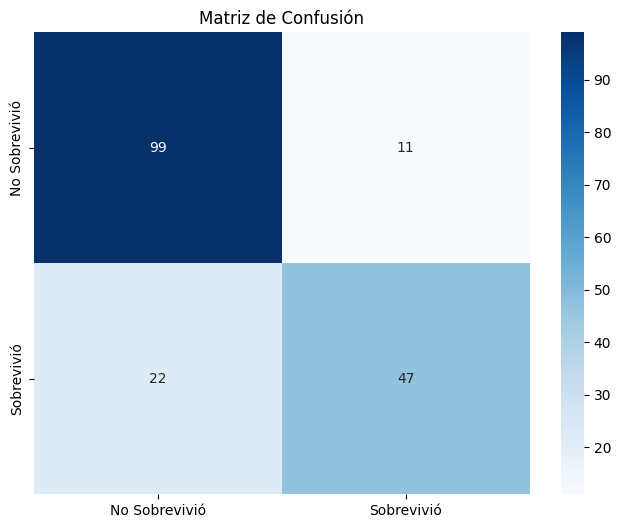

ROC AUC: 0.8506


In [19]:
print("\nEVALUACIÓN REGRESIÓN LOGÍSTICA")
evaluar_modelo(logreg_pipeline, X_test, y_test)

### Evaluar Random Forest


EVALUACIÓN RANDOM FOREST

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



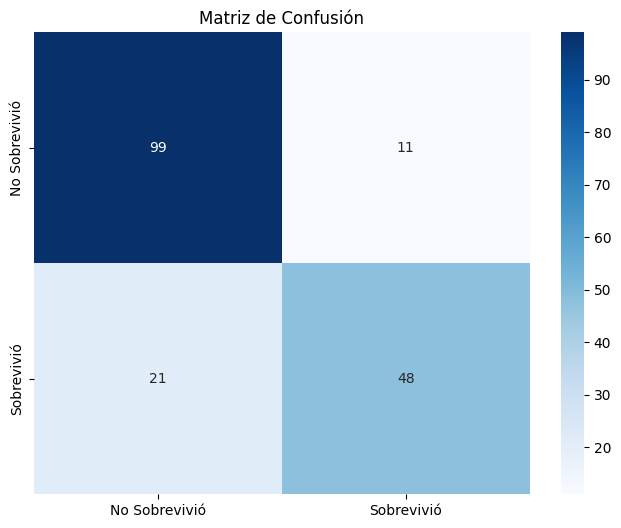

ROC AUC: 0.8220


In [20]:

print("\nEVALUACIÓN RANDOM FOREST")
evaluar_modelo(rf_pipeline, X_test, y_test)

## 7. OPTIMIZACIÓN DE HIPERPARÁMETROS (Opcional)
### Definir parámetros a probar

In [21]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],  # Parámetro de regularización
    'classifier__solver': ['liblinear', 'lbfgs']  # Algoritmo de optimización
}

### Configurar búsqueda

In [22]:
grid_search = GridSearchCV(
    logreg_pipeline,
    param_grid,
    cv=5,  # Validación cruzada de 5 folds
    scoring='roc_auc',
    n_jobs=-1  # Usar todos los núcleos del CPU
)

### Ejecutar búsqueda

In [23]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sc

### Mostrar mejores parámetros

In [24]:
print(f"\nMejores parámetros: {grid_search.best_params_}")
print(f"Mejor ROC AUC: {grid_search.best_score_:.4f}")


Mejores parámetros: {'classifier__C': 1, 'classifier__solver': 'liblinear'}
Mejor ROC AUC: 0.8559


### Evaluar mejor modelo


EVALUACIÓN MEJOR MODELO

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



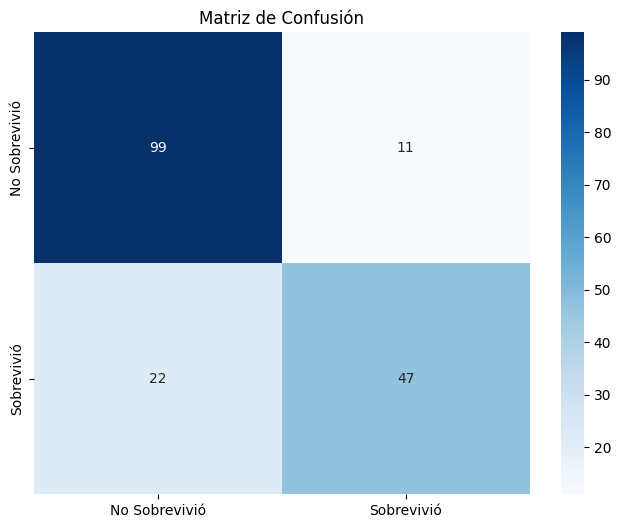

ROC AUC: 0.8506


In [25]:
best_model = grid_search.best_estimator_
print("\nEVALUACIÓN MEJOR MODELO")
evaluar_modelo(best_model, X_test, y_test)

## 8. GUARDAR MODELO (Opcional)

In [26]:
joblib.dump(best_model, 'mejor_modelo_titanic.pkl')
print("Modelo guardado como 'mejor_modelo_titanic.pkl'")

Modelo guardado como 'mejor_modelo_titanic.pkl'


### Curva ROC

La curva ROC (Receiver Operating Characteristic) muestra cómo cambia el rendimiento del modelo cuando se ajusta el umbral de decisión.
- El eje X representa la tasa de falsos positivos.
- El eje Y representa la tasa de verdaderos positivos o recall.
- Mientras más cerca esté la curva de la esquina superior izquierda, mejor separa el modelo las clases.
- El área bajo la curva (AUC) resume ese rendimiento: cuanto más cerca de 1, mejor.

Esta gráfica sirve para ver si el modelo distingue bien entre quienes sobrevivieron y quienes no, no solo con una sola métrica.

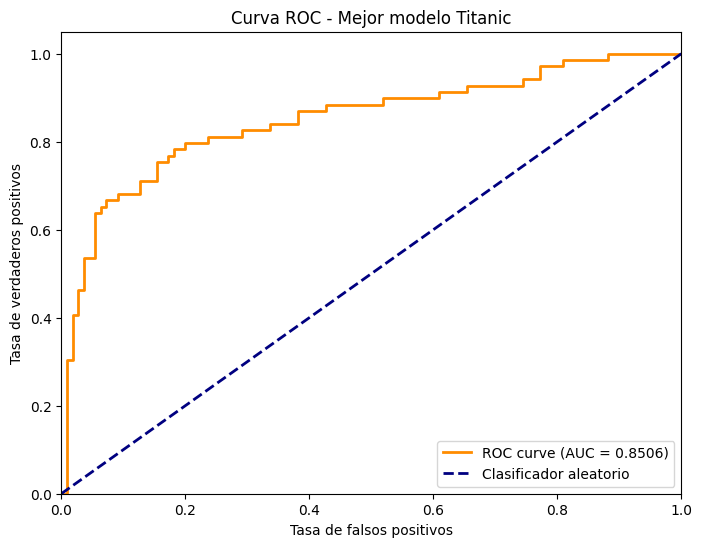

In [27]:
from sklearn.metrics import roc_curve, auc

# Probabilidades de la clase positiva
# Usamos el mejor modelo ya entrenado en el notebook
y_prob = best_model.predict_proba(X_test)[:, 1]

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Dibujar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC - Mejor modelo Titanic')
plt.legend(loc='lower right')
plt.show()